<a href="https://colab.research.google.com/github/fabiospiazzi/Proj_Final_Mod1_SCTec/blob/develop/Projeto_Final_Mod_1_SCTEC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

O Problema: Um parque fabril monitorado por sensores necessita prever quebras mecânicas nos equipamentos para evitar paradas na linha de produção. A variável alvo do projeto é binária: Falha = 1 (quando há uma avaria detectada) e Falha = 0 (funcionamento normal).

# Carregando os Dados

In [121]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')
#

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [122]:
# Carregar arquivo CSV
import pandas as pd

# Caminho do meu drive. Para reprodução em outra máquina, baixar o arquivo CSV e alterar o caminho
caminho = '/content/drive/MyDrive/Curso SCTec/IA para análise preditiva 300 h/Projeto Final - Mod_1/manutencao_preditiva.csv'
dados = pd.read_csv(caminho) # Configuraçãoes default do pandas read CSV.
dados.head()

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0


In [123]:
# Separação Target e Preditoras para EDA

y = dados['falha_maquina']    # Target
X = dados.iloc[:, 2:8]        # Preditoras
dados_juntados = pd.concat([X, y], axis=1) # Dados juntados para serem limpos
dados_juntados.head()

,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina
0,M,298.1,308.6,1551.0,42.8,0,0
1,L,298.2,308.7,1408.0,46.3,3,0
2,L,298.1,308.5,1498.0,49.4,5,0
3,L,NaN,NaN,NaN,NaN,7,0
4,L,298.2,308.7,1408.0,40.0,9,0


In [124]:
# Cabeçalho da Target
y.head()

,falha_maquina
0,0
1,0
2,0
3,0
4,0


In [125]:
# Cabeçalho das Preditoras
X.head()

,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min
0,M,298.1,308.6,1551.0,42.8,0
1,L,298.2,308.7,1408.0,46.3,3
2,L,298.1,308.5,1498.0,49.4,5
3,L,NaN,NaN,NaN,NaN,7
4,L,298.2,308.7,1408.0,40.0,9


# FASE 1 - Análise Exploratória

## - Apresente as dimensões do dataset (número de linhas e colunas), os tipos de dados das variáveis e o resumo estatístico descritivo das colunas numéricas via método “.describe()”.

In [126]:
# Todo o Dataset
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   udi                      10000 non-null  int64  
 1   id_produto               10000 non-null  object 
 2   tipo                     10000 non-null  object 
 3   temperatura_ar_k         9500 non-null   float64
 4   temperatura_processo_k   9500 non-null   float64
 5   velocidade_rotacao_rpm   9500 non-null   float64
 6   torque_nm                9500 non-null   float64
 7   desgaste_ferramenta_min  10000 non-null  int64  
 8   falha_maquina            10000 non-null  int64  
 9   falha_twf                10000 non-null  int64  
 10  falha_hdf                10000 non-null  int64  
 11  falha_pwf                10000 non-null  int64  
 12  falha_osf                10000 non-null  int64  
 13  falha_rnf                10000 non-null  int64  
dtypes: float64(4), int64(8)

É possível observar na célula acima que o dataset possui, na sua maioria, 10000 registros com 14 colunas, sendo que há algumas colunas com apenas 9500, ou seja, deverão ser tratado quanto a valores NaN.

In [127]:
# Todo o Dataset
dados.describe()

,udi,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
count,10000.00000,9500.000000,9500.000000,9500.000000,9500.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.002158,310.000895,1539.245263,39.974168,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.001689,1.486432,180.273589,9.995453,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.100000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1504.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1613.000000,46.700000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [128]:
# Estrutuda do Datase das Variáveis Preditoras
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   tipo                     10000 non-null  object 
 1   temperatura_ar_k         9500 non-null   float64
 2   temperatura_processo_k   9500 non-null   float64
 3   velocidade_rotacao_rpm   9500 non-null   float64
 4   torque_nm                9500 non-null   float64
 5   desgaste_ferramenta_min  10000 non-null  int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 468.9+ KB


In [129]:
# Estatística Descritiva das Variáveis Preditoras
X.describe()

,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min
count,9500.000000,9500.000000,9500.000000,9500.000000,10000.000000
mean,300.002158,310.000895,1539.245263,39.974168,107.951000
std,2.001689,1.486432,180.273589,9.995453,63.654147
min,295.300000,305.700000,1168.000000,3.800000,0.000000
25%,298.300000,308.800000,1423.000000,33.100000,53.000000
50%,300.100000,310.100000,1504.000000,40.100000,108.000000
75%,301.500000,311.100000,1613.000000,46.700000,162.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000


## - Plote, no mínimo, 3 gráficos analíticos bem fundamentados utilizando bibliotecas como Matplotlib ou Seaborn (Ex: histograma de distribuição das variáveis preditoras, gráfico de barras comprovando a taxa de desbalanceamento da variável alvo e um mapa de calor com a correlação de Pearson entre as variáveis).

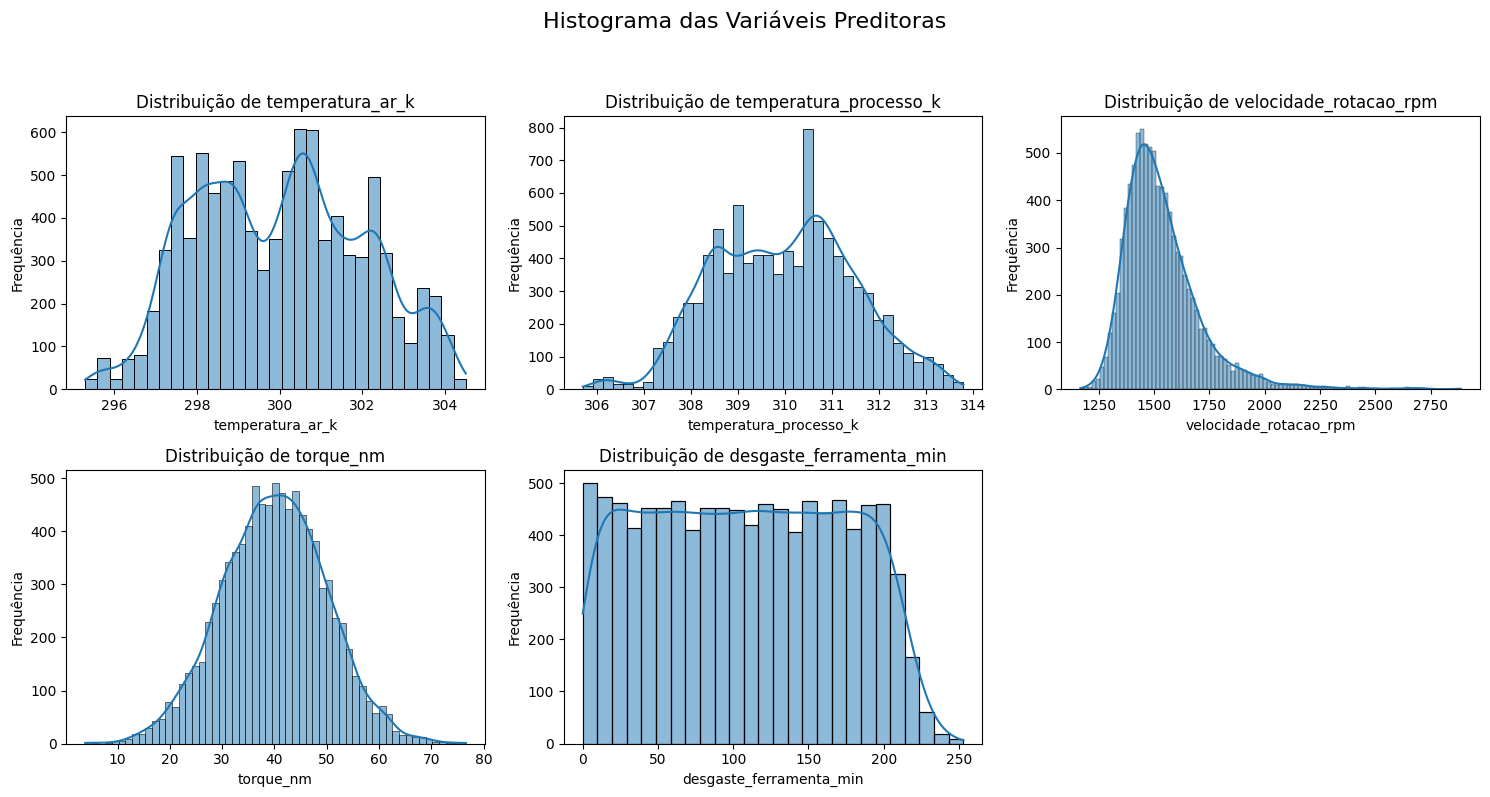

In [130]:
# Histograma das variáveis preditoras
import matplotlib.pyplot as plt
import seaborn as sns

# Selecionando apenas as colunas numéricas de X
numerical_cols = X.select_dtypes(include=['number']).columns

# Determinando o número de linhas e colunas para os subplots
n_cols = 3  # 3 colunas de histogramas
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols # Calcula o número de linhas necessário

plt.figure(figsize=(n_cols * 5, n_rows * 4))
plt.suptitle('Histograma das Variáveis Preditoras', y=1.02, fontsize=16)

for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(X[col].dropna(), kde=True) # dropna() para lidar com NaN e kde para estimativa de densidade
    plt.title(f'Distribuição de {col}')
    plt.xlabel(col)
    plt.ylabel('Frequência')

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Ajusta o layout para evitar sobreposição
plt.show()

Nos gráficos (de Histograma) acima, podemos observar a distribuição das variáveis preditoras do dataset, ainda sem limpeza e tratamento, ou seja, os dados originais (raw). Visualmente ja é possível identificar alguns possíveis pontos de outliers, como no caso da variável "temperatura_processo_k".

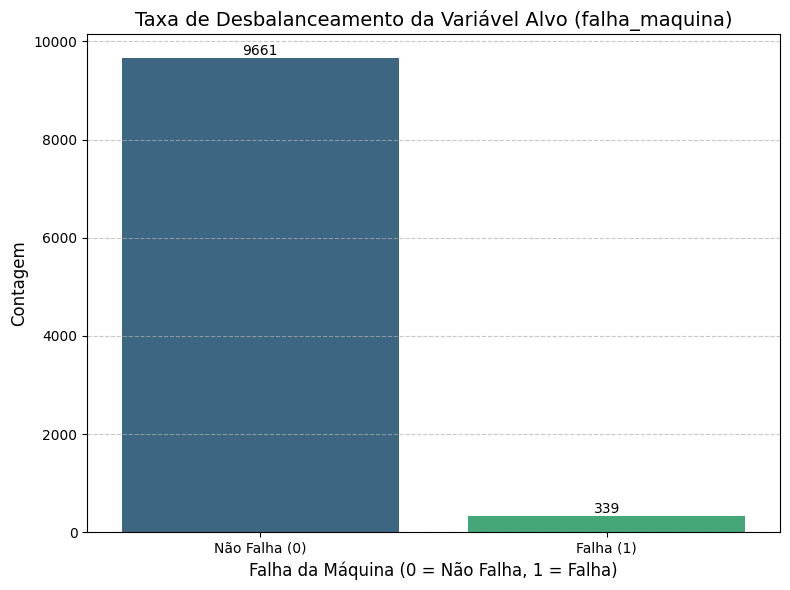

In [131]:
# Gráfico de barras para verificar a taxa de desbalanceamento entre as classes
# da variável alvo (target) - "falha_maquina".

import matplotlib.pyplot as plt
import seaborn as sns

# Contar as ocorrências de cada classe na variável alvo
imbalance_counts = y.value_counts()

# Criar o gráfico de barras
plt.figure(figsize=(8, 6))
sns.barplot(x=imbalance_counts.index, y=imbalance_counts.values, hue=imbalance_counts.index, palette='viridis', legend=False)
plt.title('Taxa de Desbalanceamento da Variável Alvo (falha_maquina)', fontsize=14)
plt.xlabel('Falha da Máquina (0 = Não Falha, 1 = Falha)', fontsize=12)
plt.ylabel('Contagem', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Não Falha (0)', 'Falha (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar os valores acima das barras
for index, value in enumerate(imbalance_counts.values):
    plt.text(index, value, str(value), ha='center', va='bottom')

plt.tight_layout()
plt.show()

A taxa de desbalanceamento do dataset é de 99,60% para a classe majoritária (Não Falha) e 0,40% para a classe minoritária (Falha), configurando um cenário de desbalanceamento extremo. No gráfico (de barras) acima é possível notar esse desbalancemento que será devidamente tratado na Fase 4 deste projeto, quando iremos separar entre treinamento e teste; e aplicar uma técnica de reamostragem (SMOTE).

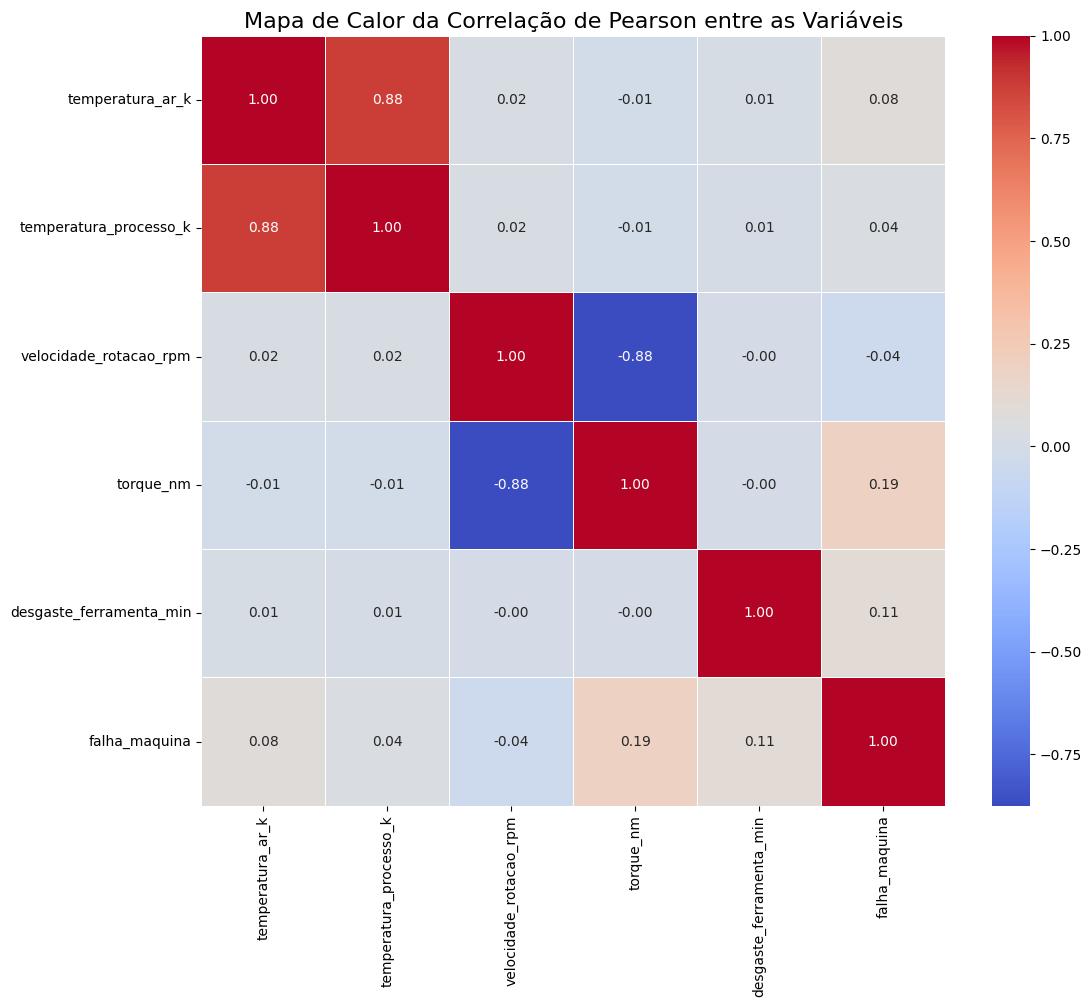

In [132]:
# Mapa de calor com a correlação de Pearson entre as variáveis
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Juntar as variáveis preditoras (X) e a variável alvo (y)
# Certificar-se de que X contém apenas colunas numéricas para o cálculo da correlação
df_corr = X.select_dtypes(include=['number']).copy()
df_corr['falha_maquina'] = y

# Calcular a matriz de correlação de Pearson
correlation_matrix = df_corr.corr(method='pearson')

# Criar o mapa de calor
plt.figure(figsize=(12, 10)) # Ajuste o tamanho conforme necessário
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Mapa de Calor da Correlação de Pearson entre as Variáveis', fontsize=16)
plt.show()

O mapa de calor da correlação de Pearson acima mostra a força da correlação direta ou indirenta entre todas as variáveis do daset. Neste primeiro momento é possível observar que há uma correlação forte entre duas variáveis preditoras (0.88), entre "temperatura_ar_k" e "temperatura_processo_k", fato que demonstra uma potencial colinearidade entre essas features preditoras. Muito provavelmente uma dessas variaveis será eliminada na fase de treinamento do modelo. Este gráfico também nos mostra uma correlação positiva, relativamente fraca, entre a variável Target "falha_maquina" e "torque_nm".

# FASE 2 - Limpeza e Tratamento de Dados (Data Prep)

## - Identifique e remova as linhas duplicadas.

In [133]:
# Identificação das linha duplicadas

dados_juntados.duplicated().sum()
print(f'Linhas duplicadas a serem removidas: {dados_juntados.duplicated().sum()}')

Linhas duplicadas a serem removidas: 185


In [134]:
# Remoção das linha duplicadas

dados_juntados.drop_duplicates(inplace=True)
print(f'Linhas duplicadas: {dados_juntados.duplicated().sum()}')

Linhas duplicadas: 0


In [135]:
# Verificação da base de dados
dados_juntados.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9815 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   tipo                     9815 non-null   object 
 1   temperatura_ar_k         9500 non-null   float64
 2   temperatura_processo_k   9500 non-null   float64
 3   velocidade_rotacao_rpm   9500 non-null   float64
 4   torque_nm                9500 non-null   float64
 5   desgaste_ferramenta_min  9815 non-null   int64  
 6   falha_maquina            9815 non-null   int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 613.4+ KB


## - Identifique dados ausentes e aplique a imputação por Média ou Mediana, justificando textualmente a escolha com base na distribuição dos dados.



## - Geração de gráficos do tipo boxplot para identificar a presença de outliers nas variáveis explicativas.

In [136]:
dados_juntados

,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina
0,M,298.1,308.6,1551.0,42.8,0,0
1,L,298.2,308.7,1408.0,46.3,3,0
2,L,298.1,308.5,1498.0,49.4,5,0
3,L,NaN,NaN,NaN,NaN,7,0
4,L,298.2,308.7,1408.0,40.0,9,0
...,...,...,...,...,...,...,...
9995,M,298.8,308.4,1604.0,29.5,14,0
9996,H,298.9,308.4,1632.0,31.8,17,0
9997,M,299.0,308.6,1645.0,33.4,22,0
9998,H,299.0,308.7,1408.0,48.5,25,0


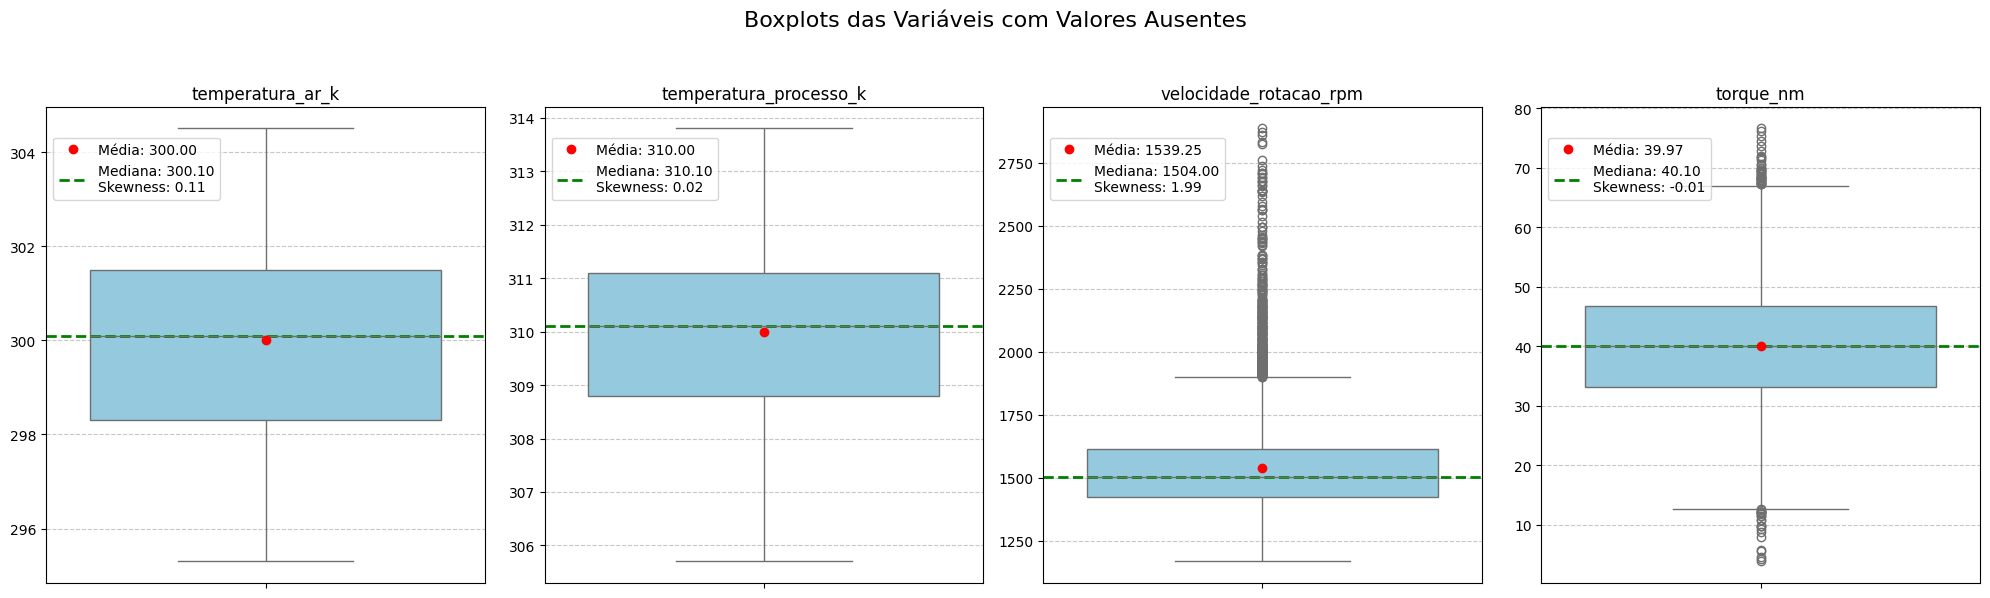


--- Estatísticas e Sugestões de Imputação ---

Variável: temperatura_ar_k
  Média: 300.00
  Mediana: 300.10
  Skewness: 0.11
  Sugestão de Imputação: Média (Skewness está entre -0.5 e 0.5)

Variável: temperatura_processo_k
  Média: 310.00
  Mediana: 310.10
  Skewness: 0.02
  Sugestão de Imputação: Média (Skewness está entre -0.5 e 0.5)

Variável: velocidade_rotacao_rpm
  Média: 1539.25
  Mediana: 1504.00
  Skewness: 1.99
  Sugestão de Imputação: Mediana (Skewness está fora do intervalo [-0.5, 0.5])

Variável: torque_nm
  Média: 39.97
  Mediana: 40.10
  Skewness: -0.01
  Sugestão de Imputação: Média (Skewness está entre -0.5 e 0.5)


In [137]:
# Regra geral para imputação:
# - Distribuição simétrica: média
# - Distribuição assimétrica: mediana

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.lines import Line2D

# Geração de Boxplots para as 4 variáveis preditoras com valores NaN

columns_to_analyze = ['temperatura_ar_k', 'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm']

n_cols = len(columns_to_analyze)
plt.figure(figsize=(n_cols * 5, 6))
plt.suptitle('Boxplots das Variáveis com Valores Ausentes', y=1.02, fontsize=16)

statistics = {}

# Itera sobre cada coluna para gerar um boxplot individual
for i, col in enumerate(columns_to_analyze):
    plt.subplot(1, n_cols, i + 1)
    # Plota o boxplot, mostrando a média com um marcador específico
    sns.boxplot(y=dados_juntados[col], color='skyblue', showmeans=True,
                meanprops={"marker":"o","markerfacecolor":"red", "markeredgecolor":"red", "markersize":"6"})

    # Calcula a média, mediana e assimetria (skewness) da coluna
    mean_val = dados_juntados[col].mean()
    median_val = dados_juntados[col].median()
    skew_val = dados_juntados[col].skew()
    statistics[col] = {'Média': mean_val, 'Mediana': median_val, 'Skewness': skew_val}

    # Cria um objeto 'proxy artist' para incluir o marcador da média na legenda
    mean_marker_handle = Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markeredgecolor='red', markersize=6, label=f'Média: {mean_val:.2f}')

    # Plota a linha da mediana e cria seu rótulo para a legenda
    median_line_handle = plt.axhline(median_val, color='green', linestyle='--', linewidth=2,
                                     label=f'Mediana: {median_val:.2f}\nSkewness: {skew_val:.2f}')

    plt.title(col)
    plt.ylabel('')

    # Combina os 'handles' e rótulos para construir a legenda
    handles = [mean_marker_handle, median_line_handle]
    labels = [h.get_label() for h in handles]

    # Ajusta a localização e posição da legenda (canto superior esquerdo, ligeiramente para baixo)
    plt.legend(handles=handles, labels=labels, loc='upper left', bbox_to_anchor=(0, 0.95))

    plt.grid(axis='y', linestyle='--', alpha=0.7)


# Ajusta o layout para evitar sobreposição dos títulos e elementos
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

# Seção complementar para imprimir estatísticas e sugestões de imputação

print('\n--- Estatísticas e Sugestões de Imputação ---')
for col, stats in statistics.items():
    print(f'\nVariável: {col}')
    print(f"  Média: {stats['Média']:.2f}")
    print(f"  Mediana: {stats['Mediana']:.2f}")
    print(f"  Skewness: {stats['Skewness']:.2f}")

    # Lógica para sugerir imputação baseada na assimetria (Skewness)
    if -0.5 <= stats['Skewness'] <= 0.5:
        print(f"  Sugestão de Imputação: Média (Skewness está entre -0.5 e 0.5)")
    else:
        print(f"  Sugestão de Imputação: Mediana (Skewness está fora do intervalo [-0.5, 0.5])")

A escolha da imputação da média ou mediana se deu por dois parâmetros principais a saber:
- Análise de distribuição dos dados: visualmente é possível observar se os dados estão uniformemente diestribuitos e se há discrepãncia entre eles. Observando os gráficos da Fase 1 dá a impressão de que a variável "temperatura_processo_k" é a menos simétrica, porém sua média e mediana são praticamente identicas, o que nos leva a segunda parte da análise,
- Coeficiente de assimetria ou Skewness, que segundo a literatura, classifica as distribuiçõesm em assimétricas e simétricas a depender deste coeficiente. Na referência que consultei, é citado um intervalo entre [-1,1], mas no código utilizei [-0.5,0.5] para ser um pouco mais criterioso. Como os dados são praticamente simétricos (Exceto para Velocidade de Rotação), somente para esta é que foi imputada a mediana. Ver referências:

George, D. Mallery, P. SPSS for Windows Step by Step: A Simple Guide and Reference. 14 ed. Taylor & Francis. 2016. Disponível em: https://knowledgezone.home.blog/wp-content/uploads/2019/05/wp-1558033893715.pdf


In [138]:
# Imputação de média e mediana nas variáveis

dados_juntados['temperatura_ar_k'] = dados_juntados['temperatura_ar_k'].fillna(dados_juntados['temperatura_ar_k'].mean())
dados_juntados['temperatura_processo_k'] = dados_juntados['temperatura_processo_k'].fillna(dados_juntados['temperatura_processo_k'].mean())
dados_juntados['velocidade_rotacao_rpm'] = dados_juntados['velocidade_rotacao_rpm'].fillna(dados_juntados['velocidade_rotacao_rpm'].median())
dados_juntados['torque_nm'] = dados_juntados['torque_nm'].fillna(dados_juntados['torque_nm'].mean())

In [139]:
# Verificação se a imputação ocrreu

dados_juntados.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9815 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   tipo                     9815 non-null   object 
 1   temperatura_ar_k         9815 non-null   float64
 2   temperatura_processo_k   9815 non-null   float64
 3   velocidade_rotacao_rpm   9815 non-null   float64
 4   torque_nm                9815 non-null   float64
 5   desgaste_ferramenta_min  9815 non-null   int64  
 6   falha_maquina            9815 non-null   int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 613.4+ KB


In [140]:
# Estatística descritiva após a imputação

dados_juntados.describe()

,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina
count,9815.000000,9815.000000,9815.000000,9815.000000,9815.000000,9815.000000
mean,300.002158,310.000895,1538.114111,39.974168,108.119511,0.034437
std,1.969303,1.462383,177.465638,9.833733,63.595598,0.182358
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,298.400000,308.900000,1425.000000,33.400000,53.000000,0.000000
50%,300.002158,310.000895,1504.000000,39.974168,108.000000,0.000000
75%,301.500000,311.000000,1609.000000,46.500000,163.000000,0.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


# FASE 3 - Feature Engineering

Criar uma nova coluna numérica por meio de operação matemática entre colunas existentes, tratando os valores nulos previamente.
Sugestão (Manutenção): potencia = velocidade_rotacao_rpm * torque_nm

## Colunas Novas Criadas
- 1. Potência Mecânica Estimada (Potência Útil)
- 2. Gradiente Térmico (Diferencial de Temperatura)
- 3. Taxa de Desgaste por Rotação (Acúmulo de Esforço)

In [141]:
# 1. Potência Mecânica Estimada (Potência Útil)

"""Na física, a potência mecânica gerada por um eixo rotativo é o produto da
velocidade de rotação pelo torque. Máquinas operando em potências extremas
ou com picos repentinos de esforço quebram mais facilmente."""

dados_juntados['potencia'] = dados_juntados['velocidade_rotacao_rpm'] * dados_juntados['torque_nm']

# 2. Gradiente Térmico (Diferencial de Temperatura)

""" A transferência de calor entre o processo e o ambiente indica a eficiência
de resfriamento da máquina. Se a temperatura do processo subir muito acima da
temperatura do ar, pode indicar falta de lubrificação, sobrecarga ou falha no
sistema de refrigeração (conhecida como falha Heat Dissipation
Failure neste dataset)."""

dados_juntados['delta_temperatura'] = dados_juntados['temperatura_processo_k'] - dados_juntados['temperatura_ar_k']

# 3. Taxa de Desgaste por Rotação (Acúmulo de Esforço)

""" O desgaste da ferramenta medido em minutos (desgaste_ferramenta_min) não
afeta a máquina da mesma forma se ela estiver girando rápido ou devagar.
Criar um indicador que multiplique o tempo de uso pela velocidade entrega a
quantidade real de fricção/giros que a ferramenta sofreu."""

dados_juntados['friccao_acumulada'] = dados_juntados['desgaste_ferramenta_min']*dados_juntados['velocidade_rotacao_rpm']

dados_juntados.head()

,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,potencia,delta_temperatura,friccao_acumulada
0,M,298.100000,308.600000,1551.0,42.800000,0,0,66382.800000,10.500000,0.0
1,L,298.200000,308.700000,1408.0,46.300000,3,0,65190.400000,10.500000,4224.0
2,L,298.100000,308.500000,1498.0,49.400000,5,0,74001.200000,10.400000,7490.0
3,L,300.002158,310.000895,1504.0,39.974168,7,0,60121.149305,9.998737,10528.0
4,L,298.200000,308.700000,1408.0,40.000000,9,0,56320.000000,10.500000,12672.0


## One-Hot Encoding (lidando com a variável categórica)

In [142]:
import pandas as pd

# Aplicar One-Hot Encoding na coluna 'tipo'
# drop_first=True para evitar a "dummy variable trap" (multicolinearidade)
# dtype=int para garantir que as novas colunas sejam de tipo inteiro (0 ou 1)
tipo_one_hot = pd.get_dummies(dados_juntados['tipo'], prefix='tipo', drop_first=True, dtype=int)

# Concatenar as novas colunas one-hot encoded com o DataFrame original
# E remover a coluna 'tipo' original
dados_juntados = pd.concat([dados_juntados.drop('tipo', axis=1), tipo_one_hot], axis=1)

# Exibir as primeiras linhas para verificar a transformação
dados_juntados.head()

,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,potencia,delta_temperatura,friccao_acumulada,tipo_L,tipo_M
0,298.100000,308.600000,1551.0,42.800000,0,0,66382.800000,10.500000,0.0,0,1
1,298.200000,308.700000,1408.0,46.300000,3,0,65190.400000,10.500000,4224.0,1,0
2,298.100000,308.500000,1498.0,49.400000,5,0,74001.200000,10.400000,7490.0,1,0
3,300.002158,310.000895,1504.0,39.974168,7,0,60121.149305,9.998737,10528.0,1,0
4,298.200000,308.700000,1408.0,40.000000,9,0,56320.000000,10.500000,12672.0,1,0


## - Extra - Correlações com as novas variáveis

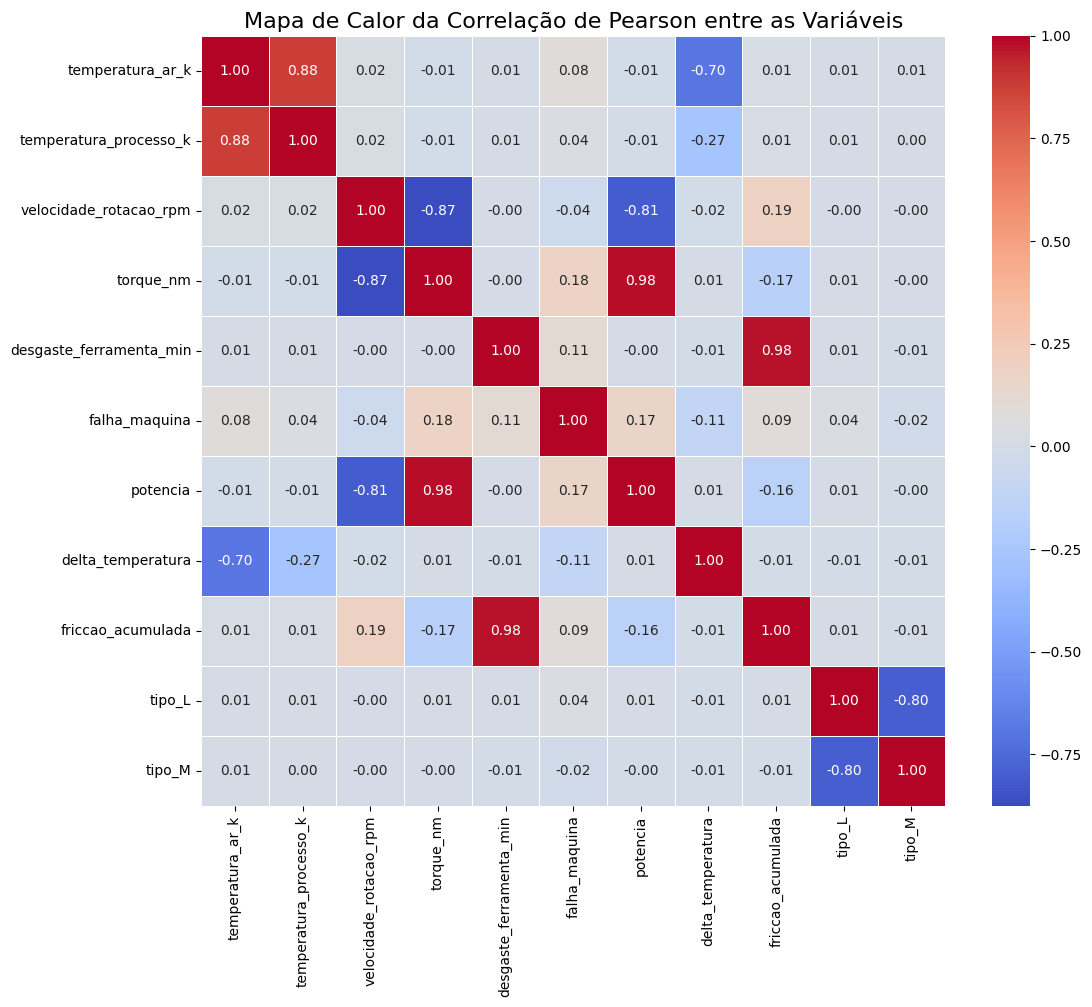

In [143]:
# Mapa de calor com a correlação de Pearson entre as variáveis
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Juntar as variáveis preditoras (X) e a variável alvo (y)
# Certificar-se de que X contém apenas colunas numéricas para o cálculo da correlação
df_corr = dados_juntados.select_dtypes(include=['number']).copy()
df_corr['falha_maquina'] = y

# Calcular a matriz de correlação de Pearson
correlation_matrix = df_corr.corr(method='pearson')

# Criar o mapa de calor
plt.figure(figsize=(12, 10)) # Ajuste o tamanho conforme necessário
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Mapa de Calor da Correlação de Pearson entre as Variáveis', fontsize=16)
plt.show()

Acima as possíveis variáveis com potencial problema de multicolinearidade:
- desgaste_ferramenta_min x friccao_acumulada
- torque_min x potencia
- velocidade_rotacao_rpm x potencia
- temperatura_ar_k x delta_temperatura
- temperatura_ar_k x temperatura_processo_k
- toque_min x velocidade x velocidade_rotacao_rpm

Utilizando o VIF para verificar a correlação entre as variáveis
-

In [144]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Classificar a correlação com base nos valores VIF
def classify_vif(vif_score):
    if vif_score == 1:
        return "VIF=1 (sem correlação)"
    elif 1 < vif_score <= 5:
        return "VIF entre 1 e 5 (correlação moderada)"
    elif 5 < vif_score <= 10:
        return "VIF 5 e 10 (correlação forte)"
    else:
        return "VIF > 10 (multicolinearidade - correlação extrema)"

def calculate_and_display_vif(df_features, iteration_name=""):
    """Calcula e exibe o VIF para as features fornecidas."""
    if df_features.empty:
        print(f"[{iteration_name}] DataFrame de features vazio. Não é possível calcular VIF.")
        return pd.DataFrame()

    # Verificar se há colunas com valores únicos que podem causar erro na inversão da matriz
    # variance_inflation_factor falha se a variância de uma coluna for 0 (todos os valores são iguais)
    cols_to_drop_for_vif = [col for col in df_features.columns if df_features[col].nunique() == 1]
    if cols_to_drop_for_vif:
        print(f"Atenção: Colunas com um único valor detectadas e temporariamente removidas para cálculo de VIF: {cols_to_drop_for_vif}")
        df_features_for_vif = df_features.drop(columns=cols_to_drop_for_vif)
    else:
        df_features_for_vif = df_features.copy()

    if df_features_for_vif.shape[1] < 2:
        print(f"[{iteration_name}] Restam menos de 2 features após remoção de colunas constantes. Não é possível calcular VIF.")
        return pd.DataFrame()

    vif_data = pd.DataFrame()
    vif_data["feature"] = df_features_for_vif.columns

    # Calcular VIF para cada feature
    vif_data["VIF"] = [variance_inflation_factor(df_features_for_vif.values.astype(float), i) for i in range(len(df_features_for_vif.columns))]
    vif_data["Classificação"] = vif_data["VIF"].apply(classify_vif)

    print(f"\n--- Análise de VIF (Variance Inflation Factor) das Variáveis Preditoras {iteration_name} ---")
    print(vif_data.sort_values(by="VIF", ascending=False).to_string(index=False))
    return vif_data

# 1. Definir o conjunto inicial de features para o VIF.
#    Começamos com 'dados_juntados' no seu estado atual, excluindo apenas a target 'falha_maquina'.
current_features = dados_juntados.drop('falha_maquina', axis=1).copy()

print("Iniciando o processo de cálculo iterativo de VIF.")
iteration = 0
vif_threshold = 10

while True:
    iteration += 1
    print(f"\n======== Iteração {iteration} ========")

    if current_features.empty:
        print("Todas as features foram removidas. Não é possível continuar o cálculo de VIF.")
        break

    vif_df = calculate_and_display_vif(current_features, f"Iteração {iteration}")

    if vif_df.empty:
        break # Sai do loop se o cálculo de VIF não foi possível (e.g., menos de 2 features)

    # Verificar se há alguma feature com VIF >= limite
    high_vif_features = vif_df[vif_df["VIF"] >= vif_threshold]

    if high_vif_features.empty:
        print(f"\nTodos os VIFs estão abaixo de {vif_threshold}. Processo concluído.")
        break
    else:
        # Remover a feature com o VIF mais alto
        feature_to_remove = high_vif_features.sort_values(by="VIF", ascending=False).iloc[0]['feature']
        print(f"\nRemovendo a feature '{feature_to_remove}' com VIF = {high_vif_features['VIF'].max():.2f} (>= {vif_threshold}).")
        current_features = current_features.drop(columns=[feature_to_remove])

    # No caso de restarem menos de 2 features, o VIF não pode ser calculado
    if current_features.shape[1] < 2:
        print("\nRestam menos de 2 features. Não é possível calcular VIF para uma única feature ou nenhuma.")
        break

print("\nProcesso de ajuste de VIF finalizado.")
print("Features finais com VIF <= 10:")
if not current_features.empty:
    print(current_features.columns.tolist())
else:
    print("Nenhuma feature restante.")

Iniciando o processo de cálculo iterativo de VIF.

======== Iteração 1 ========

--- Análise de VIF (Variance Inflation Factor) das Variáveis Preditoras Iteração 1 ---
                feature         VIF                                      Classificação
       temperatura_ar_k         inf VIF > 10 (multicolinearidade - correlação extrema)
 temperatura_processo_k         inf VIF > 10 (multicolinearidade - correlação extrema)
      delta_temperatura         inf VIF > 10 (multicolinearidade - correlação extrema)
               potencia 1175.393230 VIF > 10 (multicolinearidade - correlação extrema)
              torque_nm  836.607091 VIF > 10 (multicolinearidade - correlação extrema)
 velocidade_rotacao_rpm  620.739465 VIF > 10 (multicolinearidade - correlação extrema)
desgaste_ferramenta_min  290.238728 VIF > 10 (multicolinearidade - correlação extrema)
      friccao_acumulada  289.677434 VIF > 10 (multicolinearidade - correlação extrema)
                 tipo_L    6.863382              

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)



--- Análise de VIF (Variance Inflation Factor) das Variáveis Preditoras Iteração 4 ---
                feature        VIF                                      Classificação
      friccao_acumulada 233.119892 VIF > 10 (multicolinearidade - correlação extrema)
desgaste_ferramenta_min 232.469462 VIF > 10 (multicolinearidade - correlação extrema)
      delta_temperatura  91.646003 VIF > 10 (multicolinearidade - correlação extrema)
 velocidade_rotacao_rpm  83.624872 VIF > 10 (multicolinearidade - correlação extrema)
              torque_nm  31.147568 VIF > 10 (multicolinearidade - correlação extrema)
                 tipo_L   6.813724                      VIF 5 e 10 (correlação forte)
                 tipo_M   3.938712              VIF entre 1 e 5 (correlação moderada)

Removendo a feature 'friccao_acumulada' com VIF = 233.12 (>= 10).

======== Iteração 5 ========

--- Análise de VIF (Variance Inflation Factor) das Variáveis Preditoras Iteração 5 ---
                feature       VIF      

O VIF (Variance Inflation Factor), ou Fator de Inflação da Variância, é uma métrica estatística utilizada para detectar a multicolinearidade. Foi optado em utilizar aqui neste projeto para embasar numericamente a tomada de decisão em excluir ou manter a feature par alimentar o modelo.

A célula acima faz o seguinte: Verififica os valores de VIF maior que 10 e elimina, roda novamente e recalcula o VIF, até sobrar somente features com VIV < 10 e pelo menos duas features (Uso de IA na construção desta função)

Referências (tem o PDF na internet):

MONTGOMERY, Douglas C.; PECK, Elizabeth A.; VINING, G. Geoffrey. Introduction to Linear Regression Analysis. 5. ed. Hoboken: John Wiley & Sons, 2012.

In [145]:
dados_juntados.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9815 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   temperatura_ar_k         9815 non-null   float64
 1   temperatura_processo_k   9815 non-null   float64
 2   velocidade_rotacao_rpm   9815 non-null   float64
 3   torque_nm                9815 non-null   float64
 4   desgaste_ferramenta_min  9815 non-null   int64  
 5   falha_maquina            9815 non-null   int64  
 6   potencia                 9815 non-null   float64
 7   delta_temperatura        9815 non-null   float64
 8   friccao_acumulada        9815 non-null   float64
 9   tipo_L                   9815 non-null   int64  
 10  tipo_M                   9815 non-null   int64  
dtypes: float64(7), int64(4)
memory usage: 920.2 KB


In [146]:
# Dataset atualizado usando o VIF

# Excluindo as variáveis que estão muito correlationadas
dados_juntados.drop([
    'delta_temperatura',
    'temperatura_processo_k',
    'temperatura_ar_k',
    'velocidade_rotacao_rpm',
    'potencia',
    'friccao_acumulada'
], axis=1, inplace=True)
dados_juntados.head()

,torque_nm,desgaste_ferramenta_min,falha_maquina,tipo_L,tipo_M
0,42.800000,0,0,0,1
1,46.300000,3,0,1,0
2,49.400000,5,0,1,0
3,39.974168,7,0,1,0
4,40.000000,9,0,1,0


# FASE 4 - Divisão e Balanceamento dos Dados

## Separação das variáveis preditoras (X) da variável alvo (y).

In [147]:
y = dados_juntados['falha_maquina']
X = dados_juntados.drop('falha_maquina', axis=1)

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)
X.head()

Shape de X: (9815, 4)
Shape de y: (9815,)


,torque_nm,desgaste_ferramenta_min,tipo_L,tipo_M
0,42.800000,0,0,1
1,46.300000,3,1,0
2,49.400000,5,1,0
3,39.974168,7,1,0
4,40.000000,9,1,0


## Dividir os dados em treino (80%) e teste (20%) utilizando o parâmetro stratify=y.

In [148]:
from sklearn.model_selection import train_test_split

# Dividir os dados em treino (80%) e teste (20%) com stratify=y
# Três seeds testadas: 42, 123, 64. Seed final: 123.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123, stratify=y)

print(f'Shape de X_train: {X_train.shape}')
print(f'Shape de X_test: {X_test.shape}')
print(f'Shape de y_train: {y_train.shape}')
print(f'Shape de y_test: {y_test.shape}')

Shape de X_train: (7852, 4)
Shape de X_test: (1963, 4)
Shape de y_train: (7852,)
Shape de y_test: (1963,)


## Aplicar uma técnica de reamostragem (SMOTE ou Random Under Sampling) exclusivamente nos dados de treino para evitar o vazamento de dados ( Data Leakage ).

In [149]:
from imblearn.under_sampling import RandomUnderSampler

# Inicializar o RandomUnderSampler
undersampler = RandomUnderSampler(random_state=42)

# Aplicar o undersampling apenas nos dados de treino
X_train_resampled, y_train_resampled = undersampler.fit_resample(X_train, y_train)

print(f'Shape de X_train original: {X_train.shape}')
print(f'Shape de y_train original: {y_train.shape}')
print(f'Shape de X_train resampled: {X_train_resampled.shape}')
print(f'Shape de y_train resampled: {y_train_resampled.shape}')

print('\nContagem de classes em y_train original:')
print(y_train.value_counts())
print('\nContagem de classes em y_train resampled:')
print(y_train_resampled.value_counts())

Shape de X_train original: (7852, 4)
Shape de y_train original: (7852,)
Shape de X_train resampled: (540, 4)
Shape de y_train resampled: (540,)

Contagem de classes em y_train original:
falha_maquina
0    7582
1     270
Name: count, dtype: int64

Contagem de classes em y_train resampled:
falha_maquina
0    270
1    270
Name: count, dtype: int64


Originalmente, o y_train tinha 7582 amostras da classe 0 e 270 da classe 1. Após o rebalanceamento, tanto o X_train_resampled quanto o y_train_resampled agora contêm 540 amostras, com a classe 0 e a classe 1 tendo 270 ocorrências cada. Isso significa que o conjunto de treino está balanceado para que o modelo não seja enviesado pela classe majoritária.

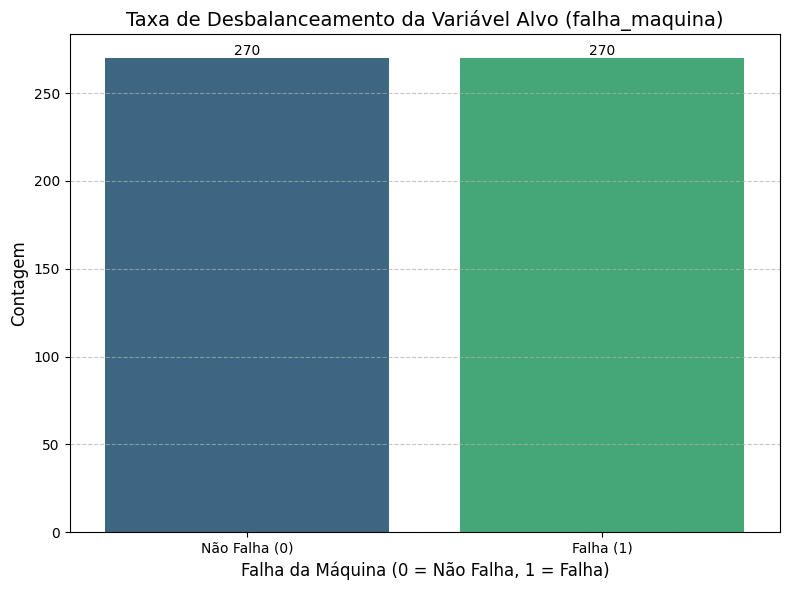

In [150]:
# Gráfico de barras para verificar o balanceamento das classes após
# aplicação da função: RandomUnderSamplerda variável alvo (target)
# - "falha_maquina".

import matplotlib.pyplot as plt
import seaborn as sns

# Contar as ocorrências de cada classe na variável alvo
imbalance_counts = y_train_resampled.value_counts()

# Criar o gráfico de barras
plt.figure(figsize=(8, 6))
sns.barplot(x=imbalance_counts.index, y=imbalance_counts.values, hue=imbalance_counts.index, palette='viridis', legend=False)
plt.title('Taxa de Desbalanceamento da Variável Alvo (falha_maquina)', fontsize=14)
plt.xlabel('Falha da Máquina (0 = Não Falha, 1 = Falha)', fontsize=12)
plt.ylabel('Contagem', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Não Falha (0)', 'Falha (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar os valores acima das barras
for index, value in enumerate(imbalance_counts.values):
    plt.text(index, value, str(value), ha='center', va='bottom')

plt.tight_layout()
plt.show()

# FASE 5 - Escalonamento de Variáveis (StandardScaler)

## - Aplique o StandardScaler apenas nas variáveis contínuas destinadas ao modelo KNN (utilizando fit_transform no treino e transform no teste).

In [151]:
# Escalonamento para o KNN

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# X do Treino (.fit_transform)
X_train_KNN_scaled = scaler.fit_transform(X_train_resampled)
X_train_KNN_scaled = pd.DataFrame(X_train_KNN_scaled, columns=X_train_resampled.columns)

# X do Teste (.transform)
X_test_KNN_scaled = scaler.transform(X_test)
X_test_KNN_scaled = pd.DataFrame(X_test_KNN_scaled, columns=X_test.columns)
#

In [152]:
X_train_KNN_scaled.head()

,torque_nm,desgaste_ferramenta_min,tipo_L,tipo_M
0,-0.209360,1.272813,0.713008,-0.585904
1,-0.266653,0.085511,0.713008,-0.585904
2,-0.173553,1.043935,-1.402510,-0.585904
3,0.650029,-1.702594,0.713008,-0.585904
4,0.564090,-1.788423,-1.402510,1.706764


In [153]:
X_test_KNN_scaled.head()

,torque_nm,desgaste_ferramenta_min,tipo_L,tipo_M
0,-0.354442,-1.130400,-1.402510,1.706764
1,0.313434,-1.187620,0.713008,-0.585904
2,0.234657,0.157035,0.713008,-0.585904
3,-0.660540,1.172679,-1.402510,1.706764
4,-0.918356,-0.572511,0.713008,-0.585904


## - Manter os dados da Árvore de Decisão sem escalonamento, justificando no código o motivo de o algoritmo ser imune à escala dos atributos.

In [154]:
print("Dados da Árvore de Decisão sem escalonamento:")
print("\nX_train_resampled")
X_train_resampled.head()
#

Dados da Árvore de Decisão sem escalonamento:

X_train_resampled


,torque_nm,desgaste_ferramenta_min,tipo_L,tipo_M
5386,42.0,214,1,0
3414,41.2,131,1,0
4021,42.5,198,0,0
1425,54.0,6,1,0
2764,52.8,0,0,1


In [155]:
print("y_train_resampled")
y_train_resampled.head()

y_train_resampled


,falha_maquina
5386,0
3414,0
4021,0
1425,0
2764,0


**Justificativa de não escalonar os dados para o Decision Tree**:

O principal motivo de não ser necessário escalonar os dados no Decision Tree é que ele é um algoritmo baseado em árvores de decisão. Essas árvores tomam decisões baseadas em regras e divisões lógicas (limiares) de cada variável individualmente, e não no cálculo de distâncias entre os pontos de dados. Como essas decisões são tomadas individualmente em cada nó da árvore, a escala das features não interfere no processo de aprendizado. Se o cálculo da distância precisa ser utilizando, então as variáveis precisam ser escalonadas (todas precisasm estar na mesma escala)

# FASE 6 - Ajuste de Parâmetros e Combate ao Overfitting

## - No KNN: Treine o modelo variando o parâmetro n_neighbors (K) por no mínimo 3 valores ímpares (ex: K = 3, 5, 7) e registre a acurácia no treino e no teste.

In [156]:
X_train_KNN_scaled.head()

,torque_nm,desgaste_ferramenta_min,tipo_L,tipo_M
0,-0.209360,1.272813,0.713008,-0.585904
1,-0.266653,0.085511,0.713008,-0.585904
2,-0.173553,1.043935,-1.402510,-0.585904
3,0.650029,-1.702594,0.713008,-0.585904
4,0.564090,-1.788423,-1.402510,1.706764


In [157]:
X_test_KNN_scaled.head()

,torque_nm,desgaste_ferramenta_min,tipo_L,tipo_M
0,-0.354442,-1.130400,-1.402510,1.706764
1,0.313434,-1.187620,0.713008,-0.585904
2,0.234657,0.157035,0.713008,-0.585904
3,-0.660540,1.172679,-1.402510,1.706764
4,-0.918356,-0.572511,0.713008,-0.585904


In [158]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = [3, 5, 7, 9, 11]
results_knn = {}

# Excluindo uma das variáveis de temperatura muito correlacionadas
# X_train_KNN_scaled_del = X_train_KNN_scaled.drop('temperatura_processo_k', axis=1)
# X_test_KNN_scaled_del = X_test_KNN_scaled.drop('temperatura_processo_k', axis=1)



for k in k_values:
    print(f"\n--- Treinando KNN com k = {k} ---")
    # Inicializar o modelo KNN
    knn = KNeighborsClassifier(n_neighbors=k)

    # Treinar o modelo usando os dados de treino reamostrados e escalonados
    # Altetar o X caso queirar usar o dataset em a coluna temperatura_processo_k
    knn.fit(X_train_KNN_scaled, y_train_resampled)

    # Fazer previsões nos dados de treino e teste
    # Altetar o X caso queirar usar o dataset em a coluna temperatura_processo_k
    y_train_pred_knn = knn.predict(X_train_KNN_scaled)
    y_test_pred_knn = knn.predict(X_test_KNN_scaled)

    # Calcular e registrar a acurácia no treino
    train_accuracy_knn = accuracy_score(y_train_resampled, y_train_pred_knn)
    print(f"Acurácia no treino (k={k}): {train_accuracy_knn:.4f}")

    # Calcular e registrar a acurácia no teste
    test_accuracy_knn = accuracy_score(y_test, y_test_pred_knn)
    print(f"Acurácia no teste (k={k}): {test_accuracy_knn:.4f}")

    results_knn[k] = {
        'train_accuracy': train_accuracy_knn,
        'test_accuracy': test_accuracy_knn
    }


--- Treinando KNN com k = 3 ---
Acurácia no treino (k=3): 0.8722
Acurácia no teste (k=3): 0.8023

--- Treinando KNN com k = 5 ---
Acurácia no treino (k=5): 0.8407
Acurácia no teste (k=5): 0.8176

--- Treinando KNN com k = 7 ---
Acurácia no treino (k=7): 0.8333
Acurácia no teste (k=7): 0.8334

--- Treinando KNN com k = 9 ---
Acurácia no treino (k=9): 0.8167
Acurácia no teste (k=9): 0.8416

--- Treinando KNN com k = 11 ---
Acurácia no treino (k=11): 0.8185
Acurácia no teste (k=11): 0.8548


## - Na Árvore: Treine o modelo variando o parâmetro max_depth por no mínimo 3 limites (ex: 3, 5 e None) e registre a acurácia no treino e no teste.

In [159]:
# Treinamento para a Árvore de Decisão
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

max_depth_values = [3, 5, 7, 9, 11, 13, None]
results_dt = {}

for depth in max_depth_values:
    print(f"\n--- Treinando Árvore de Decisão com max_depth = {depth} ---")
    # Inicializar o modelo de Árvore de Decisão

    dt = DecisionTreeClassifier(max_depth=depth, random_state=42) # random_state para reprodutibilidade

    # Treinar o modelo usando os dados de treino reamostrados (não escalonados)
    dt.fit(X_train_resampled, y_train_resampled)

    # Fazer previsões nos dados de treino e teste
    y_train_pred_dt = dt.predict(X_train_resampled)
    y_test_pred_dt = dt.predict(X_test)

    # Calcular e registrar a acurácia no treino
    train_accuracy_dt = accuracy_score(y_train_resampled, y_train_pred_dt)
    print(f"Acurácia no treino (max_depth={depth}): {train_accuracy_dt:.4f}")

    # Calcular e registrar a acurácia no teste
    test_accuracy_dt = accuracy_score(y_test, y_test_pred_dt)
    print(f"Acurácia no teste (max_depth={depth}): {test_accuracy_dt:.4f}")

    results_dt[depth] = {
        'train_accuracy': train_accuracy_dt,
        'test_accuracy': test_accuracy_dt
    }


--- Treinando Árvore de Decisão com max_depth = 3 ---
Acurácia no treino (max_depth=3): 0.8407
Acurácia no teste (max_depth=3): 0.8747

--- Treinando Árvore de Decisão com max_depth = 5 ---
Acurácia no treino (max_depth=5): 0.8593
Acurácia no teste (max_depth=5): 0.8762

--- Treinando Árvore de Decisão com max_depth = 7 ---
Acurácia no treino (max_depth=7): 0.8852
Acurácia no teste (max_depth=7): 0.8492

--- Treinando Árvore de Decisão com max_depth = 9 ---
Acurácia no treino (max_depth=9): 0.9222
Acurácia no teste (max_depth=9): 0.8268

--- Treinando Árvore de Decisão com max_depth = 11 ---
Acurácia no treino (max_depth=11): 0.9500
Acurácia no teste (max_depth=11): 0.8023

--- Treinando Árvore de Decisão com max_depth = 13 ---
Acurácia no treino (max_depth=13): 0.9704
Acurácia no teste (max_depth=13): 0.7687

--- Treinando Árvore de Decisão com max_depth = None ---
Acurácia no treino (max_depth=None): 1.0000
Acurácia no teste (max_depth=None): 0.7636


## Inserir um texto identificando em quais pontos ocorreu o overfitting e qual configuração garantiu a estabilidade no teste.

- Considerando o SEED = 123
- Para o KNN o overfitting aparente ocorreu quando o **k=3**, onde a acurária do no conjunto de treinamento foi de 0.8722 (87,22%) e no cojunto de teste foi de 0.8023 (80,23%). Importante notar que nesta configuração há a maior discrepância nas acurácias entre treinamento e teste. Já a estabilidade do modelo ocorreu quando **k=7**, onde para acurácia no treinamento foi de 0,8333 (83,33%) e no teste foi de 0,8334 (83,34%) sendo que nesta configuração ocorreu a menor diferença entre a acurácia do conjunto de treinamento e o conjunto de teste (apenas 0.0001)

- Para o Decision Tree, o overfitting ocorreu com a configuração do max_depth = None, onde a acurácia no conjunto de dados de treino chegou a 1 (100%). Já a estabilidade ocorreu quando o max_dept = 5, sendo que a acurácia do treinamento foi de 0,8593 (85,93%) e no conjunto de teste foi de 0,8792 (87,92%)

# FASE 7 - Avaliação da Acurácia e Veredito Final

## - Calcule e exiba a acurácia final do melhor KNN e da melhor árvore de decisão utilizando os dados de teste.

Foram testados 3 diferentes conjuntos de dados (seeds)

* 42
* 123
* 64

Com base nas estatísticas apresentadas na figura abaixo (tabela comparativa), optou-se por manter o KNN, devido ao menor desvio padrão da acurácia no conjunto de teste. Na célula abaixo, é mostrado a acurácia do seed 123.

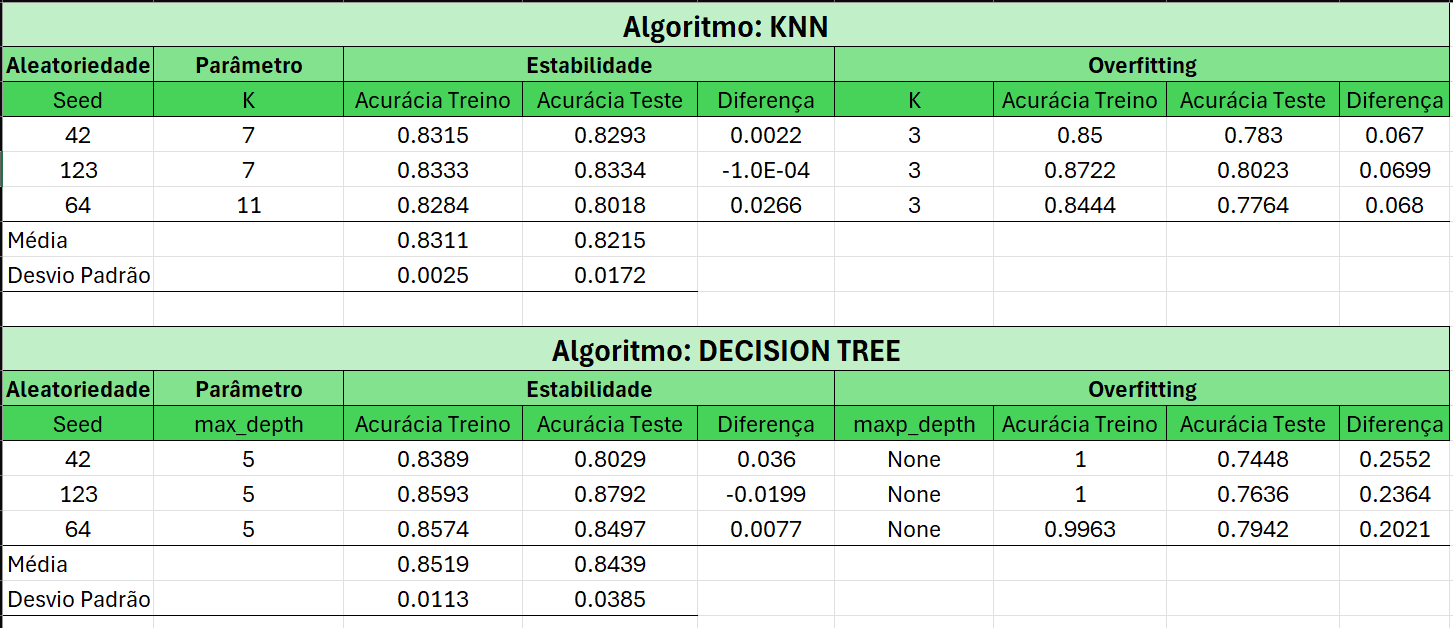

In [161]:
# Acurácia Final para o KNN
print(f"\nAcurácia Final para o KNN (K=7): {results_knn[7]['test_accuracy'] * 100:.2f}%")

# Acurácia Final para a Árvore de Decisão
print(f"\nAcurácia Final para a Árvore de Decisão (Profundidade = 5): {results_dt[5]['test_accuracy'] * 100:.2f}%")

# Modelo Escolhido
print(f"\nModelo Escolhido: \n\nDecision Tree com: {results_dt[5]['test_accuracy'] * 100:.2f}% de acurácia nos dados de teste")


Acurácia Final para o KNN (K=7): 83.34%

Acurácia Final para a Árvore de Decisão (Profundidade = 5): 87.62%

Modelo Escolhido: 

Decision Tree com: 87.62% de acurácia nos dados de teste


## - Compare as taxas de acerto e escreva uma conclusão justificando qual modelo apresentou o desempenho superior no teste e deve ser adotado pela empresa.

Comparando os dois modelos em questão (KNN e Decision Tree), nota-se que o **DECISION TREE** acabou desempenhando uma eficiência ligeiramente maior na previsão dos resultados na classificações das possíveis falhas nas máquinas da empresa, com uma acurácia **MÉDIA** (com base ndos 3 seeds) de 84,39% (Taxa de Acerto), contra 82,15% do modelo KNN. Assim, optamos por indicar o modelo **DECISION TREE** para ser adotado pela empresa, até que um outro modelo com uma maior eficácia seja ajustado.